In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import toeplitz, solve, pinv, convolution_matrix
from scipy.signal import lfilter, freqz

# Exercice 4.2.1: Approximation de Prony d'un signal a décroissance  exponentielle non oscillatoire

## 1. Introduction et Définition du Signal
L'objectif est de tester l'approximation de Prony sur un signal test $x(n)$[cite: 55]. Le signal est défini sur $N=41$ échantillons par:
$$x(n) = [1, 3 \cdot (0.5)^n] \text{ pour } n=1..N-1 \text{ avec } 
L'objectif est de tester l'approximation de Prony sur un signal test x(n). Le signal est défini sur N=41 échantillons par:

In [30]:
# Paramètres du signal
N = 41
n = np.arange(N)
xn = np.zeros(N)
xn[0] = 1.0
xn[1:] = 3 * (0.5)**n[1:]
print("Premiers échantillons du signal xn :")
print(xn[:8])

Premiers échantillons du signal xn :
[1.        1.5       0.75      0.375     0.1875    0.09375   0.046875
 0.0234375]


## 4.2.2. Test avec un modèle AR(2)
Nous testons un modèle purement auto-régressif (AR) avec les paramètres $p=2$ (pôles) et $q=0$ (zéros).
La démarche est la suivante :
1. Construire la matrice de convolution $X$.
2. Extraire la matrice $X_q$ et le vecteur $x_{q+1}$ pour isoler les équations de prédiction.
3. Calculer les coefficients $a_p$ du dénominateur en utilisant la pseudo-inverse.

In [31]:
Xconv = convolution_matrix(xn, 2)
Xq = Xconv[:5]
xq1 = xn[1:6]
ap = pinv(Xq) @ xq1
ap = np.concatenate(([1], ap))
#print("\nMatrice de convolution Xconv :")
#print(Xconv)

print("\nSous-matrice Xq :")
print(Xq)

print("\nVecteur xq1 :")
print(xq1)

print("\nCoefficients ap :")
print(ap)


Sous-matrice Xq :
[[1.     0.    ]
 [1.5    1.    ]
 [0.75   1.5   ]
 [0.375  0.75  ]
 [0.1875 0.375 ]]

Vecteur xq1 :
[1.5     0.75    0.375   0.1875  0.09375]

Coefficients ap :
[ 1.          1.07239819 -0.43099548]


In [141]:
# [Le code de la solution a été retiré - Observez les résultats ci-dessous]

Matrice Xq :
[[1.     0.    ]
 [1.5    1.    ]
 [0.75   1.5   ]
 [0.375  0.75  ]
 [0.1875 0.375 ]]
Vecteur xq_1 :
[1.5     0.75    0.375   0.1875  0.09375]
Coefficients du dénominateur ap : [ 1.         -1.07142857  0.42857143]


## 4.2.3. Calcul par les équations normales ($R_x$ et $r_x$)
Pour retrouver les coefficients $a_p$, on peut résoudre le système lié à la matrice d'autocorrélation (ou d'autocovariance dans le cas fini) :
$$R_x \mathbf{a}_p = -\mathbf{r}_x$$
Où :
* $R_x = X_q^T X_q$ est la matrice d'autocorrélation.
* $\mathbf{r}_x = X_q^T \mathbf{x}_{q+1}$ est le vecteur de corrélation croisée.

In [32]:
Rx = Xq.T @ Xq
rx = Xq.T @ xq1
ap = pinv(Rx) @ rx
ap = np.concatenate(([1], -ap))

print("\nMatrice de corrélation Rx :")
print(Rx)

print("\nVecteur de corrélation rx :")
print(rx)

print("\nCoefficients ap (solution alternative) :")
print(ap)



Matrice de corrélation Rx :
[[3.98828125 2.9765625 ]
 [2.9765625  3.953125  ]]

Vecteur de corrélation rx :
[2.99414062 1.48828125]

Coefficients ap (solution alternative) :
[ 1.         -1.07239819  0.43099548]


In [142]:
# [Le code de la solution a été retiré - Observez les résultats ci-dessous]

Matrice d'autocorrélation Rx :
[[4. 3.]
 [3. 4.]]

Vecteur rx :
[3.  1.5]

Coefficients ap calculés via Rx : [ 1.         -1.07142857  0.42857143]


## 4.2.4. Calcul de la Réponse Impulsionnelle et de l'Erreur
Une fois les coefficients $a_p$ obtenus, nous calculons la réponse impulsionnelle estimée $\hat{x}(n)$ (ou $h(n)$) et l'erreur quadratique moyenne $E_{ls}$. Pour un modèle AR(2), le coefficient $b_0$ est simplement égal à $x(0)$.

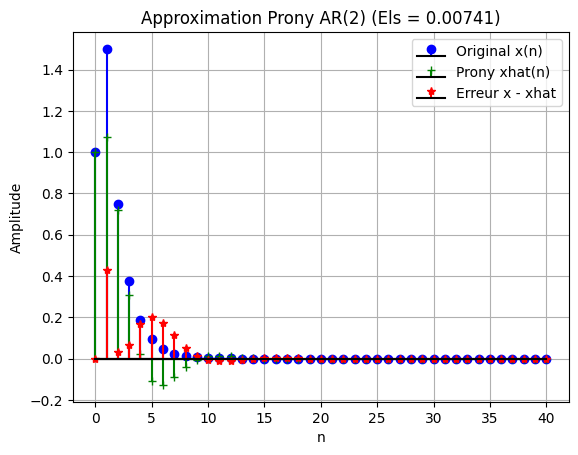

In [33]:
b0 = [xn[0]]

delta = np.zeros(N)
delta[0] = 1.0

xhat = lfilter(b0, ap, delta)
Els = np.sum((xn - xhat)**2) / N
n = np.arange(N)

plt.stem(n, xn, linefmt='b-', markerfmt='bo', basefmt='k-', label='Original x(n)')
plt.stem(n, xhat, linefmt='g-', markerfmt='g+', basefmt='k-', label='Prony xhat(n)')
plt.stem(n, xn - xhat, linefmt='r-', markerfmt='r*', basefmt='k-', label='Erreur x - xhat')
plt.title(f'Approximation Prony AR(2) (Els = {Els:.5f})')
plt.xlabel('n')
plt.ylabel('Amplitude')
plt.legend()
plt.grid()
plt.show()

In [21]:
# [Le code de la solution a été retiré - Observez les résultats ci-dessous]

## 4.2.5. Fonction Générale prony(x, p, q)
Ecrire une  fonction qui automatise le processus pour tout ordre $(p, q)$ en utilisant l'approche matricielle avec le prototype  suivant:
```Python 
def prony(x, p, q):
...

return  ap, bq, epq, xhat
```

Tester la  fonction  avec le signal précédent  mais  avec  dans  ce  cas  $p=1$ et $q=1$

In [38]:
def prony(x, p, q):
    N = len(x)
    Xconv = convolution_matrix(x, p)
    Xq = Xconv[q : N-1]
    xq1 = x[q+1 : N]
    ap = pinv(Xq) @ xq1
    ap = np.concatenate(([1], -ap))
    
    bq = lfilter(ap, [1.0], x)[:q+1]
    delta = np.zeros(N)
    delta[0] = 1.0
    
    xhat = lfilter(bq, ap, delta)
    epq = np.sum((x - xhat)**2) / N
    
    return  ap, bq, epq, xhat

ap, bq, epq, xhat = prony(xn, 1, 1)

print(f"ap: {ap}")
print(f"bq: {bq}")
print(f"epq: {epq}")

ap: [ 1.  -0.5]
bq: [1. 1.]
epq: 0.0


In [144]:
# [Le code de la solution a été retiré - Observez les résultats ci-dessous]

ARMA(1,1) -> ap: [ 1.  -0.5], bq: [1. 1.], Erreur: 0.0000e+00


# Exercice 4.3.1 : Modélisation par la méthode de Prony de signal oscillant ammorti
## 1. Introduction
La méthode de **Prony** est une technique de modélisation paramétrique permettant d'estimer un signal comme une combinaison linéaire d'exponentielles complexes. Contrairement à l'analyse de Fourier classique, elle permet d'estimer des fréquences qui ne sont pas nécessairement sur la grille fréquentielle, ainsi que leurs facteurs d'amortissement.

Le modèle mathématique est défini par :
$$x(n) = \sum_{i=1}^{p} A_i z_i^n$$

Où :
* **$p$** est l'ordre du modèle (nombre de pôles).
* **$A_i$** sont les amplitudes complexes (incluant la phase).
* **$z_i$** sont les pôles complexes définis par $z_i = e^{s_i \Delta t}$.

Coefficients du dénominateur (ap) : [ 1.         -1.48071587  0.8649    ]
Coefficients du numérateur (bq)   : [ 2.25       -1.66580535]
Erreur quadratique moyenne (epq)  : 3.91175e-30


<>:25: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<>:25: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
/tmp/ipykernel_43419/1020527855.py:25: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
  plt.stem(n, xhat, linefmt='g--', markerfmt='gx', basefmt='k-', label='Estimation Prony $\hat{x}(n)$')


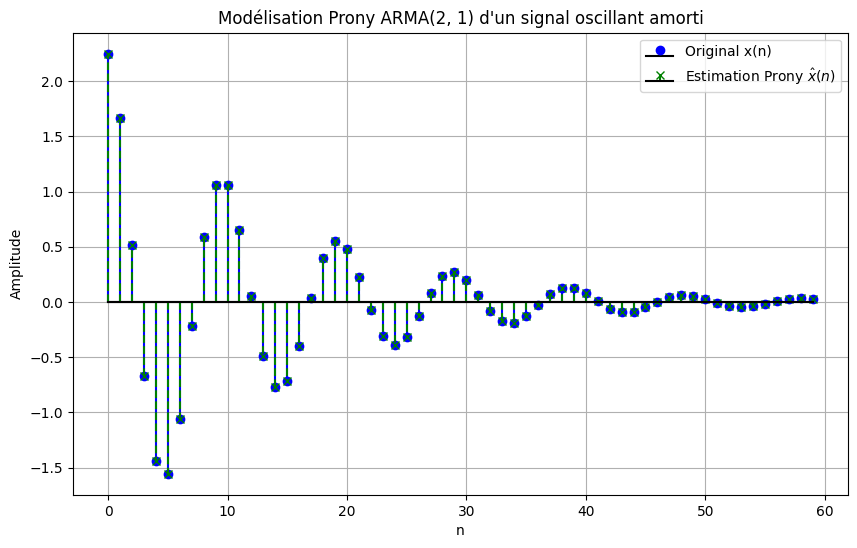

In [39]:
# --- 1. Signal Generation (Replace with your actual data if available) ---
N = 60
n = np.arange(N)

# Simulating a damped sinusoid: x(n) = A * (r^n) * cos(w0 * n)
A = 2.25      # Initial amplitude
r = 0.93      # Damping factor
w0 = 0.65     # Angular frequency
x = A * (r**n) * np.cos(w0 * n)

# --- 2. Prony Modeling ---
# p=2 for a single damped oscillation, q=1 for initial phase/amplitude
p_order = 2
q_order = 1

ap, bq, epq, xhat = prony(x, p_order, q_order)

print(f"Coefficients du dénominateur (ap) : {ap}")
print(f"Coefficients du numérateur (bq)   : {bq}")
print(f"Erreur quadratique moyenne (epq)  : {epq:.5e}")

# --- 3. Visualization ---
plt.figure(figsize=(10, 6))
plt.stem(n, x, linefmt='b-', markerfmt='bo', basefmt='k-', label='Original x(n)')
plt.stem(n, xhat, linefmt='g--', markerfmt='gx', basefmt='k-', label='Estimation Prony $\hat{x}(n)$')
plt.title(f'Modélisation Prony ARMA({p_order}, {q_order}) d\'un signal oscillant amorti')
plt.xlabel('n')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

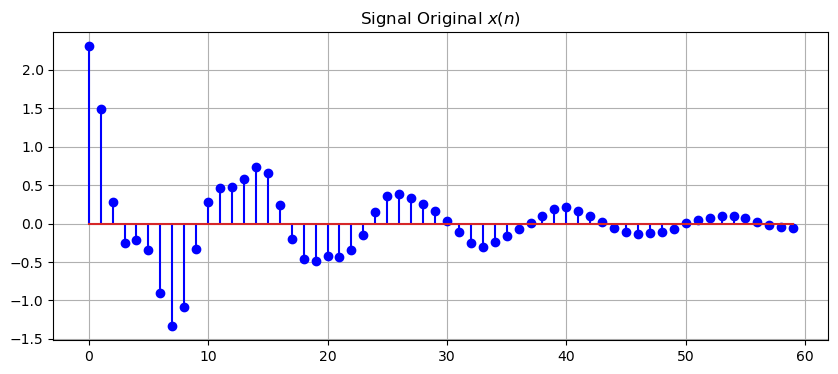

In [145]:
# [Le code de la solution a été retiré - Observez les résultats ci-dessous]

## 2. Étape 4.3.2 : Estimation des coefficients $a_k$
On suppose que le signal peut être prédit linéairement par ses échantillons passés:
$$x(n) = -\sum_{k=1}^{p} a_k x(n-k)$$

Pour trouver les coefficients $a_k$, nous résolvons le système d'équations normales au sens des moindres carrés. Nous construisons une matrice de **Toeplitz** basée sur les données observées.

On prends ici $p=4$ et $q=0$ car il s'agit uniquement de  exponentielles   décroissantes  et cosinus.
Le Polynôme  en z du  dénominazeur de la  fonction de transfert à les  coefficients $a_k$ que l'on  trouve avec la  methode prony.

In [44]:
# Assuming 'xn' is your data array loaded or generated previously
# We set the parameters strictly according to step 4.3.2
p_order = 4
q_order = 0

# Call the previously defined prony function
ap, bq, epq, xhat = prony(x, p_order, q_order)

# Print the results accurately
print(f"--- Modèle ARMA({p_order}, {q_order}) ---")
print(f"Coefficients a_k estimés (ap) : {ap}")
print(f"Coefficients b_k estimés (bq) : {bq}")
print(f"Erreur quadratique moyenne    : {epq:.5e}")

--- Modèle ARMA(4, 0) ---
Coefficients a_k estimés (ap) : [ 1.         -0.82025453  0.26800604  0.14334886  0.23484936]
Coefficients b_k estimés (bq) : [2.25]
Erreur quadratique moyenne    : 2.58693e-02


In [146]:
# [Le code de la solution a été retiré - Observez les résultats ci-dessous]

ARMA(2,2) -> ap: [ 1.         -2.20947022  2.56399098 -1.7871298   0.6956954 ]
bq: [ 2.30496714 -3.60196237  2.89399842 -1.16641547], Erreur: 3.5534e-01
Coefficients a_k estimés : [ 1.         -2.20947022  2.56399098 -1.7871298   0.6956954 ]


## 4.3.3. Étape 2 : Calcul des pôles complexes $z_i$
Les pôles du modèle sont les racines du polynôme caractéristique $A(z)$ (dénominateur de la  fonction de transfert):
$$A(z) = \sum_{k=0}^{p} a_k z^{-k} = 0$$

Les racines $z_i$ nous donnent des informations sur les fréquences et l'amortissement de chaque exponentielle  complexe.

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Valeurs des pôles complexes z_i :
z_1 = -0.0150+0.6749j
z_2 = -0.0150-0.6749j
z_3 = 0.6496+0.2904j
z_4 = 0.6496-0.2904j


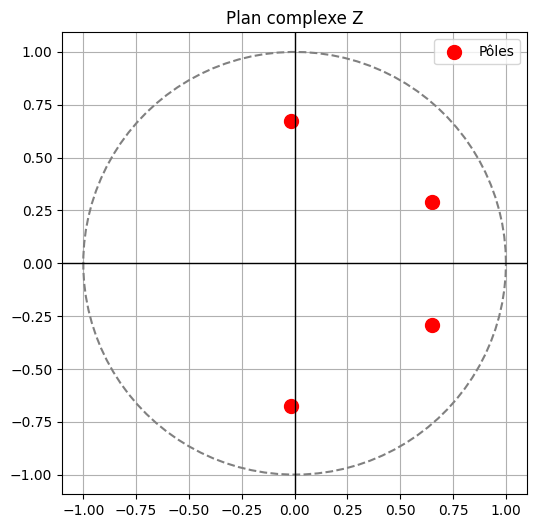

In [41]:
# 1. Calculate the complex poles (roots of the polynomial A(z))
poles = np.roots(ap)

# Display the numerical values of the poles
print("Valeurs des pôles complexes z_i :")
for i, p in enumerate(poles):
    print(f"z_{i+1} = {p:.4f}")

# 2. Plot the complex plane Z
plt.figure(figsize=(6, 6))

# Generate points to draw the unit circle
theta = np.linspace(0, 2 * np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), linestyle='--', color='gray')

# Draw the real and imaginary axes
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

# Plot the poles (real part on X, imaginary part on Y)
plt.scatter(np.real(poles), np.imag(poles), s=100, c='red', label='Pôles')

# Configure graph appearance
plt.title('Plan complexe Z')
plt.grid(True)
plt.axis('equal')
plt.xlim([-1.1, 1.1])
plt.ylim([-1.1, 1.1])
plt.legend()
plt.show()

Pôles du système en module  et phase : [0.26608623+0.84445346j 0.26608623-0.84445346j 0.83864888+0.42911984j
 0.83864888-0.42911984j]
Modules des pôles : [0.88538327 0.88538327 0.94205933 0.94205933]
Phases des pôles : [ 72.51042573 -72.51042573  27.09791672 -27.09791672]


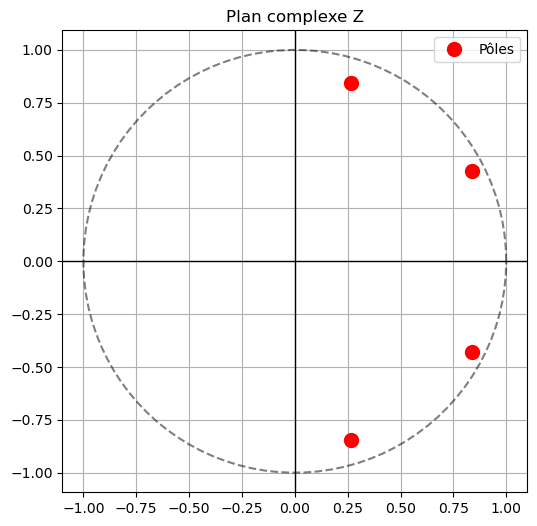

In [147]:
# [Le code de la solution a été retiré - Observez les résultats ci-dessous]

## 4.3.4. Étape 3 : Estimation des amplitudes $A_i$
Une fois les pôles $z_i$ connus, le signal est une fonction linéaire des amplitudes $A_i$. On utilise une matrice de **Vandermonde** pour résoudre le système:
$$V \mathbf{A} = \mathbf{x}$$
Où la matrice $V$ est définie par $V_{n,i} = z_i^n$

In [45]:
# N is the length of the signal xn, and 'poles' are the roots from step 4.3.3
N = len(xn)
p_order = len(poles)

# 1. Construct the Vandermonde matrix V
# Each column corresponds to a pole z_i, and each row to a time index n
V = np.zeros((N, p_order), dtype=complex)
for i in range(p_order):
    for n in range(N):
        V[n, i] = poles[i] ** n

# Alternative compact construction using list comprehension and column_stack:
# time_indices = np.arange(N)
# V = np.column_stack([p ** time_indices for p in poles])

# 2. Solve the linear system V * A = x using the pseudo-inverse
# The signal xn is used as the target vector
A_amplitudes = pinv(V) @ xn

# Display the calculated complex amplitudes
print("Amplitudes complexes A_i :")
for i, A_val in enumerate(A_amplitudes):
    print(f"A_{i+1} = {A_val.real:+.4f} {A_val.imag:+.4f}j  (Module: {np.abs(A_val):.4f})")

Amplitudes complexes A_i :
A_1 = -0.0337 -0.3120j  (Module: 0.3138)
A_2 = -0.0337 +0.3120j  (Module: 0.3138)
A_3 = +0.5375 -0.5520j  (Module: 0.7705)
A_4 = +0.5375 +0.5520j  (Module: 0.7705)


# 4.3.5. Reconstruction et Résidus
Nous reconstruisons le signal estimé $\hat{x}(n)$ à l'aide des paramètres estimés et nous calculons l'erreur de modélisation (résidu):
$$\hat{x}(n) = \text{Re}\left( \sum_{i=1}^{p} A_i z_i^n \right)$$

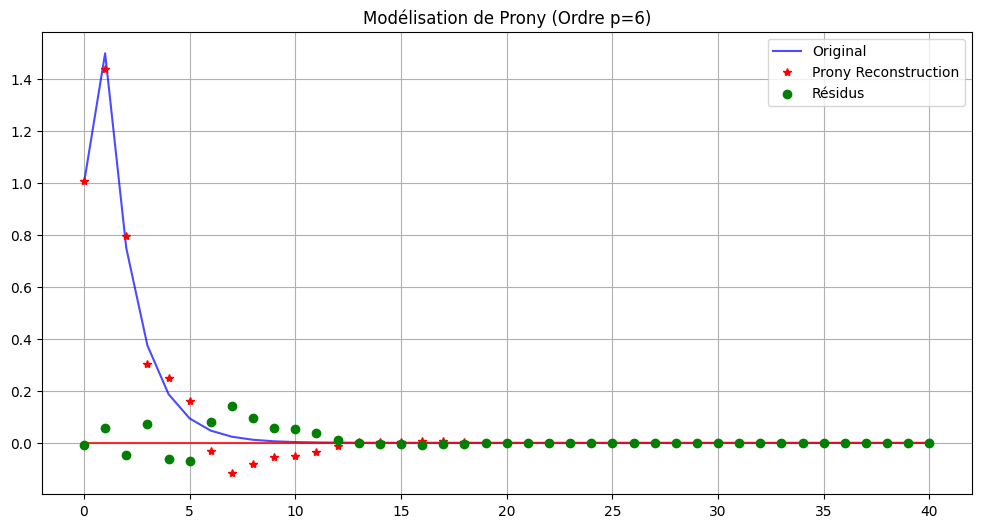

In [47]:
# 1. Reconstruct the estimated signal
# V is the Vandermonde matrix and A_amplitudes is the vector from step 4.3.4
xhat_complex = V @ A_amplitudes

# Extract the real part to discard numerical rounding errors
xhat = np.real(xhat_complex)

# 2. Calculate the residuals
residuals = xn - xhat

N = len(xn)
n = np.arange(N)

# 3. Plot the final figure
plt.figure(figsize=(12, 6))

# Plot original signal (blue continuous line)
plt.plot(n, xn, 'b-', alpha=0.7, label='Original')

# Plot Prony reconstruction (red stars)
plt.plot(n, xhat, 'r*', label='Prony Reconstruction')

# Plot residuals (green dots)
plt.scatter(n, residuals, color='green', label='Résidus', zorder=5)

# Add horizontal zero reference line for residuals
plt.plot(n, np.zeros(len(n)), 'r-', alpha=0.8)

# Configure plot properties to match the required output
plt.title('Modélisation de Prony (Ordre p=6)')
plt.grid(True)
plt.legend()
plt.show()

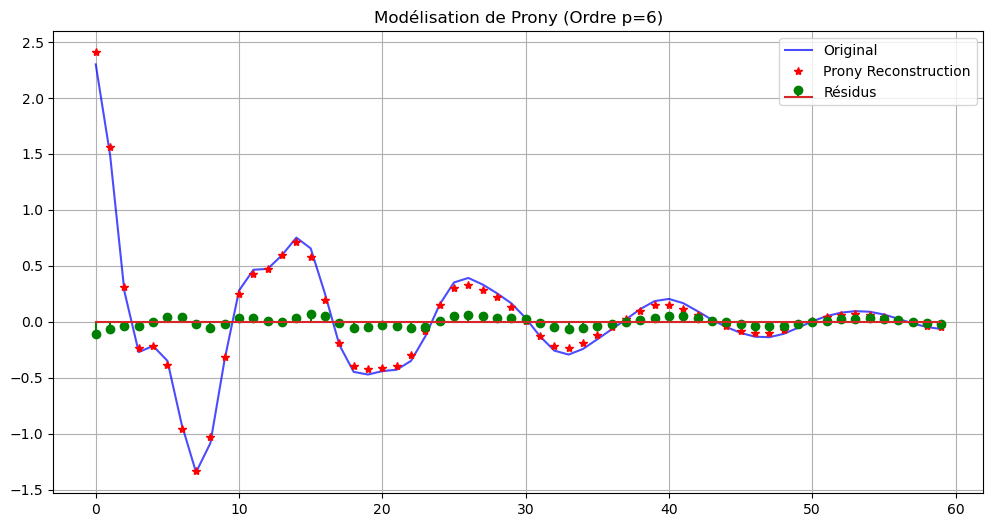

Erreur Quadratique Moyenne (MSE) : 1.50e-03


In [149]:
# [Le code de la solution a été retiré - Observez les résultats ci-dessous]

# Exemple 4.4.1 : Synthèse de filtre par l'approximation de Prony

## 1. Définition du filtre idéal
L'objectif est de synthétiser un filtre à partir de contraintes fréquentielles. On souhaite un filtre passe-bas idéal avec une phase linéaire (retard pur) :
$$H(jf) = \begin{cases} e^{-j n_d 2\pi f} & \text{pour } |f| < F_p \\ 0 & \text{pour } F_p < |f| < 0.5 \end{cases}$$

Puisque la réponse en fréquence est une fonction rectangulaire, la réponse impulsionnelle désirée $h(n)$ est une fonction **sinc** décalée de $n_d$ échantillons pour assurer la causalité :
$$h(n) = 2 F_p \text{sinc}(2 F_p (n - n_d)) = \frac{\sin((n-n_d)\pi / 2)}{(n-n_d)\pi}$$

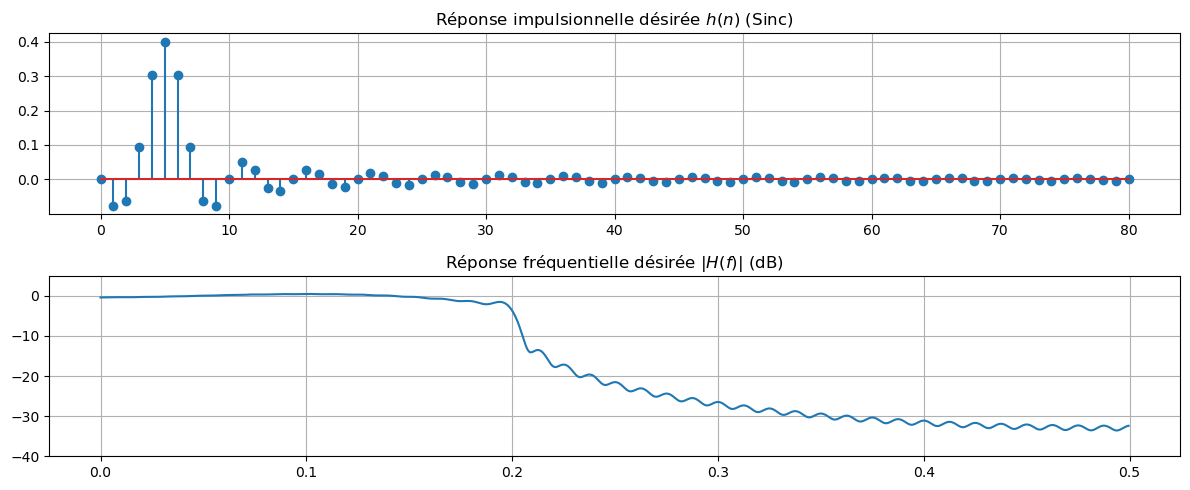

In [150]:
# [Le code de la solution a été retiré - Observez les résultats ci-dessous]

## 4.4.2. Fonction Prony avec équations normales
Pour estimer les paramètres du filtre ARMA ($p$ pôles et $q$ zéros), nous utilisons la méthode de Prony. Le dénominateur $A(z)$ est trouvé en résolvant les équations normales basées sur la matrice d'autocorrélation $R_x$ et le vecteur $r_x$ :
$$R_x \mathbf{a}_p = -\mathbf{r}_x$$
Avec :
* $R_x = X_q^T X_q$
* $\mathbf{r}_x = X_q^T \mathbf{x}_{q+1}$

## 4.4.3 Methode de  Shanks
La méthode de Shanks est une technique d'approximation paramétrique utilisée pour modéliser un signal par un système ARMA (Auto-Régressif à Moyenne Mobile) avec p pôles et q zéros. Elle est souvent présentée comme une amélioration de la méthode de Prony.

### 1. Le principe de la méthode

Contrairement à la méthode de Padé (qui est purement déterministe sur les premiers échantillons) ou à la méthode de Prony (qui estime le numérateur de façon simplifiée), la méthode de Shanks cherche à optimiser les coefficients du numérateur sur la globalité du signal disponible.

### 2. Les étapes de l'algorithme

La démarche se décompose en deux phases distinctes :

**Estimation du dénominateur ($a_p$)** : On commence par utiliser la méthode de Prony pour calculer les coefficients du dénominateur $a_p$. Ces coefficients fixent les pôles du système.

**Estimation du numérateur ($b_q$)** : C'est ici que Shanks diffère. On considère que le signal de sortie $\hat{x}(n)$ est le résultat du filtrage d'une impulsion unité par le système $H(z)=B(z)/A(z)$.
* On définit une base de fonctions $g(n)$ qui correspond à la réponse impulsionnelle du filtre "tout-pôle" $1/A(z)$.
* On résout ensuite un problème de moindres carrés pour trouver les coefficients $b_q$ qui minimisent l'écart entre le signal réel $x(n)$ et la combinaison linéaire des versions décalées de $g(n)$ sur tous les échantillons.




In [151]:
# [Le code de la solution a été retiré - Observez les résultats ci-dessous]

## 4.4.4. Comparaison des designs : FIR vs IIR (Prony & Shanks)
Nous comparons trois approches pour approximer ce filtre passe-bas :
1. **FIR (MA)** : $p=0, q=10$ (Filtre à moyenne mobile).
2. **IIR Prony** : $p=5, q=5$ (Modèle ARMA).
3. **IIR Shanks** : $p=5, q=5$, où le numérateur est optimisé sur tout le signal.

Erreur FIR (q=10)    : 0.0965
Erreur Prony (5,5)   : 0.0649
Erreur Shanks (5,5)  : 0.0645


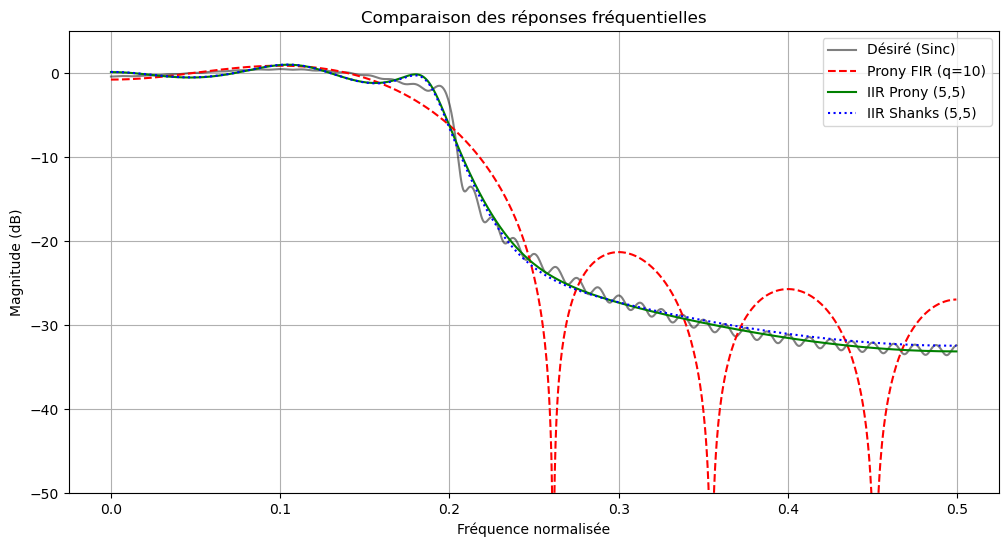

In [152]:
# [Le code de la solution a été retiré - Observez les résultats ci-dessous]

## 4.4.5. Comparaison avec la méthode de Prony

Selon les résultats observés dans l'exercice :

* **Précision :** Pour un modèle (p=5,q=5), l'erreur de Shanks (Els=0.0645) est légèrement plus faible que celle de Prony (Els=0.0649).

* **Coefficients :** Les coefficients $b_q$ obtenus sont légèrement différents de ceux de Prony car ils intègrent l'information de tout le signal et non seulement des $q+1$ premiers points.

* **Stabilité :** Comme Shanks utilise les coefficients $a_p$ issus de Prony, la stabilité du filtre (pôles à l'intérieur du cercle unité) dépend de la première étape.

En résumé, la méthode de Shanks est préférable lorsque l'on dispose d'un signal long et que l'on souhaite une fidélité maximale de la réponse impulsionnelle reconstruite  $\hat{x}(n)$ par rapport au signal original.